In [33]:
import os
import numpy as np
import pandas as pd
from anndata import AnnData
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
# Set figure parameters
sc.set_figure_params(dpi=100, vector_friendly=True) 
# vector_friendly=True rasterizes large objects (such as dots in a scatterplot as pixels).
# More at https://scanpy.readthedocs.io/en/stable/generated/scanpy.set_figure_params.html

In [30]:
## read processed Xenium data
data = sc.read("xenium_4donors_processed.h5ad")

ℹ️ There are cases were we want to detect in space the places/zones where 2 or more cell types are together.  
For glomeruli, these would be poodcytes, perietal epithelial cells, mesangial cells etc.,  
For [tertiary lymphoid structures](https://www.biorxiv.org/content/10.1101/2024.12.26.630405v1.full) (TLS), these would be colocalization of T and B cells in close proximity,  
For inflamed tissue detection, these would be colocalization of immune cells and tissue cells, e.g. colocalized proximal tubules (PT)
and immune cells may indicate inflamed tubulointerstitial areas.

In these cases, an algoritm like [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) is quite useful and may be better compared to other algorithms.

DBSCAN has following parameters:
1. eps: Maximum distance between two points to be considered neighbors. This controls neighborhood size 
2. min_samples: Minimum number of points required to form a dense region/cluster. This controls minimum cluster size  
Each distinct localized region is assigned a value. Points that don't meet these criteria are labeled as noise (-1)

Below we'll run DBSCAN on identifying TLS regions. There is a very closely related method [TLS Finder](https://www.biorxiv.org/content/10.1101/2024.12.26.630405v1.full) [[Code]](https://github.com/AAKoksoy/TLS-Finder).


First let's check nichePCA clusters against cell types. Cell type labels for this data are available in /home/shared/spatial-workshop-GCB-2025/cell_types_xenium_4donors.csv

In [45]:
df = pd.read_csv("cell_types_xenium_4donors.csv", index_col=0).loc[data.obs_names]
data.obs["cell_type"] = df["cell_type"].astype("category")

In [34]:
## Create a new anndata where "cells" are cell type composition per cluster for a donor.
cluster_col = 'nichePCA_cluster'
celltype_col = 'cell_type'
donor_col = 'Donor'

# Extract relevant columns from original data
obs_df = data.obs[[donor_col, cluster_col, celltype_col]].copy()

composition_list = []
metadata_list = []

# Group by donor and cluster to get cell type composition for each cluster
for (donor, cluster), group in obs_df.groupby([donor_col, cluster_col]):
    # Count cells of each type in this cluster
    celltype_counts = group[celltype_col].value_counts()
    total_cells = len(group)
    
    # Convert to proportions
    composition = celltype_counts / total_cells
    
    composition_list.append(composition)
    metadata_list.append({
        donor_col: donor,
        cluster_col: cluster,
        'n_cells': total_cells
    })

# Create composition matrix (rows = donor-cluster combos, columns = cell types)
X = pd.DataFrame(composition_list).fillna(0).values

# Create obs with donor, cluster, and cell count info
obs = pd.DataFrame(metadata_list)
obs.index = obs[donor_col].astype(str) + '_' + obs[cluster_col].astype(str)

# Create var with cell type names
var = pd.DataFrame(index=pd.DataFrame(composition_list).columns)

# Create new AnnData object
data_comp = AnnData(X=X, obs=obs, var=var)

/tmp/ipykernel_3110/29474570.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (donor, cluster), group in obs_df.groupby([donor_col, cluster_col]):


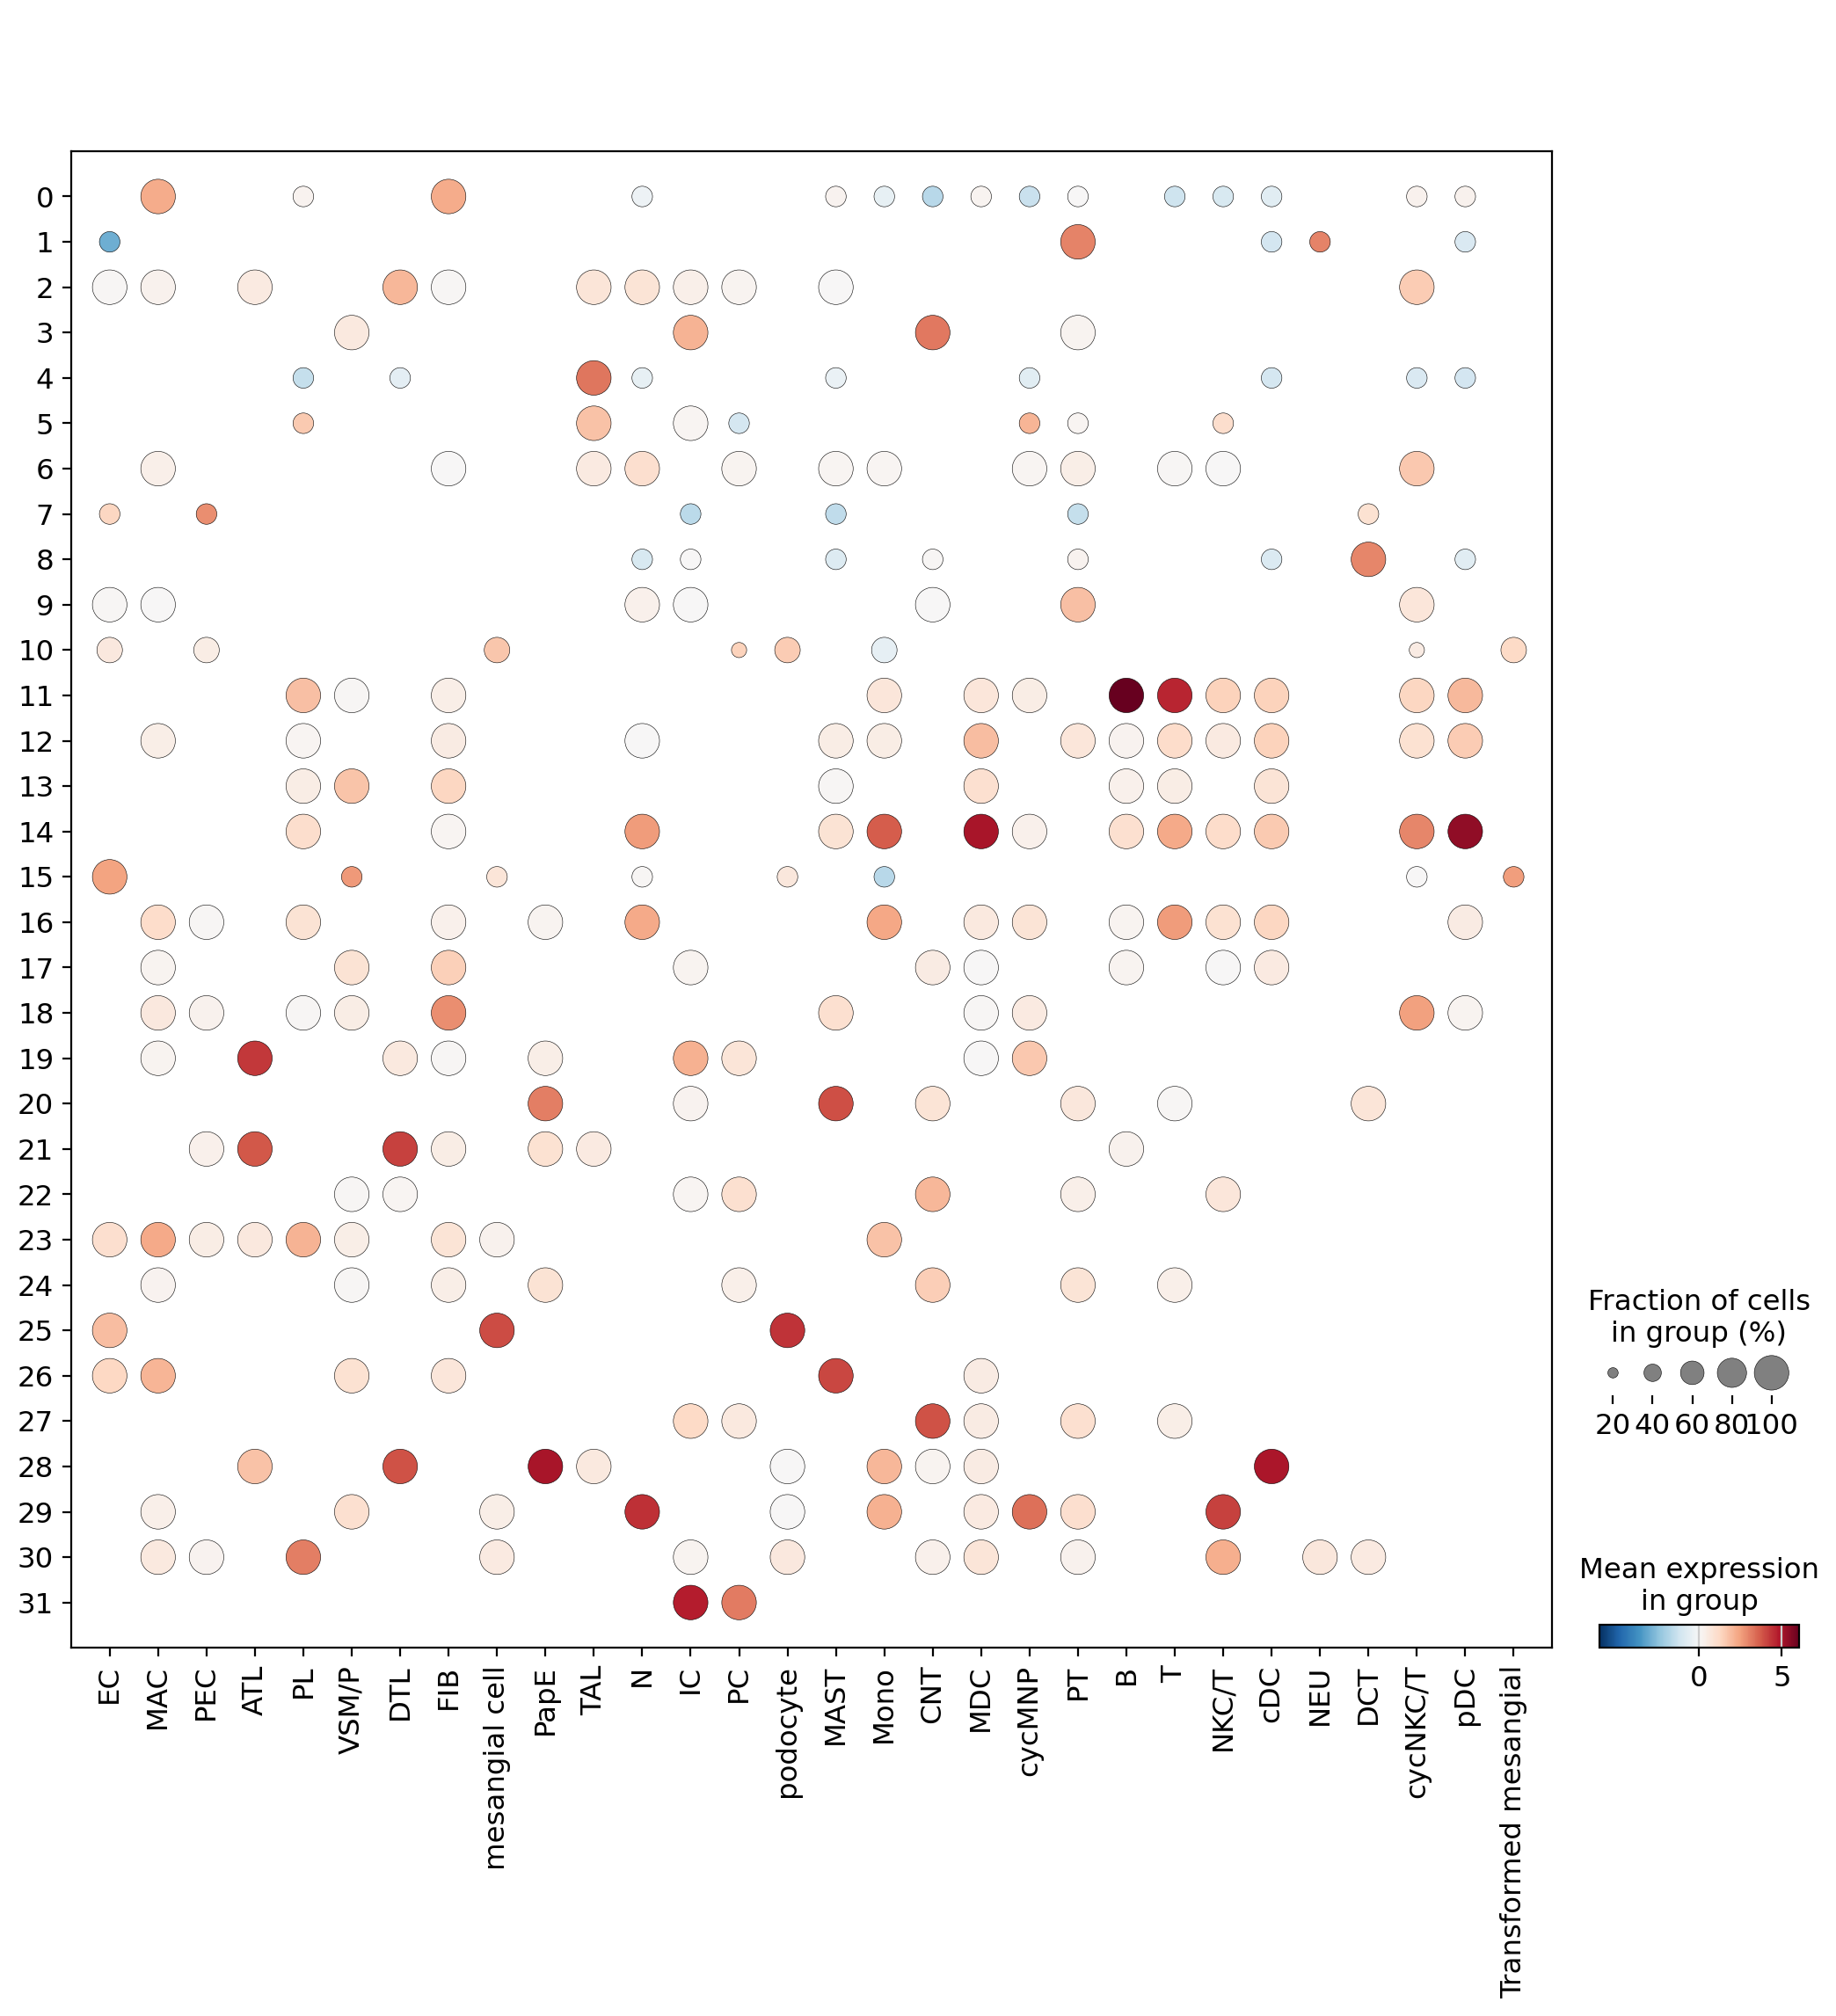

In [37]:
## plot cell type composition
sc.pp.scale(data_comp, max_value=10) # scale for better visualization
celltypes = data.obs[celltype_col].unique()
sc.pl.dotplot(data_comp, groupby="nichePCA_cluster", var_names=celltypes, vcenter=0, cmap="RdBu_r")

<u>Question:</u> 
Is there any nichePCA cluster that can labelled as TLS, based on the definition? 

In [39]:
from sklearn.cluster import DBSCAN

# Get T and B cell positions
t_cells = data[data.obs['cell_type'] == 'T']
b_cells = data[data.obs['cell_type'] == 'B']

# Combine T and B cell coordinates
tb_indices = np.concatenate([t_cells.obs_names, b_cells.obs_names])
tb_coords = np.vstack([
    data[t_cells.obs_names].obsm['spatial'],
    data[b_cells.obs_names].obsm['spatial']
])

# Run DBSCAN
dbscan = DBSCAN(eps=50, min_samples=20)
clusters = dbscan.fit_predict(tb_coords)

# Initialize all cells as -1 (not in T/B colocalization zones)
data.obs['DBSCAN_cluster'] = "-1"

# Assign cluster labels to T and B cells
for idx, cell_name in enumerate(tb_indices):
    data.obs.loc[cell_name, 'DBSCAN_cluster'] = str(clusters[idx])

In [40]:
## The above script only annotates T&B cells as TLS
# Assign cells within a distance to the assigned clusters

from sklearn.neighbors import NearestNeighbors

# Get cells that were assigned to DBSCAN clusters (not noise)
clustered_cells = data.obs['DBSCAN_cluster'] != "-1"
clustered_coords = data[clustered_cells].obsm['spatial']
clustered_labels = data[clustered_cells].obs['DBSCAN_cluster'].values

# Get unclustered cells
unclustered_cells = data.obs['DBSCAN_cluster'] == "-1"
unclustered_coords = data[unclustered_cells].obsm['spatial']

# Find nearest clustered neighbor for each unclustered cell
nbrs = NearestNeighbors(n_neighbors=1).fit(clustered_coords)
distances, indices = nbrs.kneighbors(unclustered_coords)

# Assign unclustered cells to nearest cluster if within distance threshold
distance_threshold = 50  # Adjust based on your tissue scale
for i, (dist, idx) in enumerate(zip(distances.flatten(), indices.flatten())):
    if dist <= distance_threshold:
        cell_name = unclustered_cells[unclustered_cells].index[i]
        data.obs.loc[cell_name, 'DBSCAN_cluster'] = clustered_labels[idx]

/tmp/ipykernel_3110/1817346483.py:9: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  sub.uns["cell_type_colors"] = []


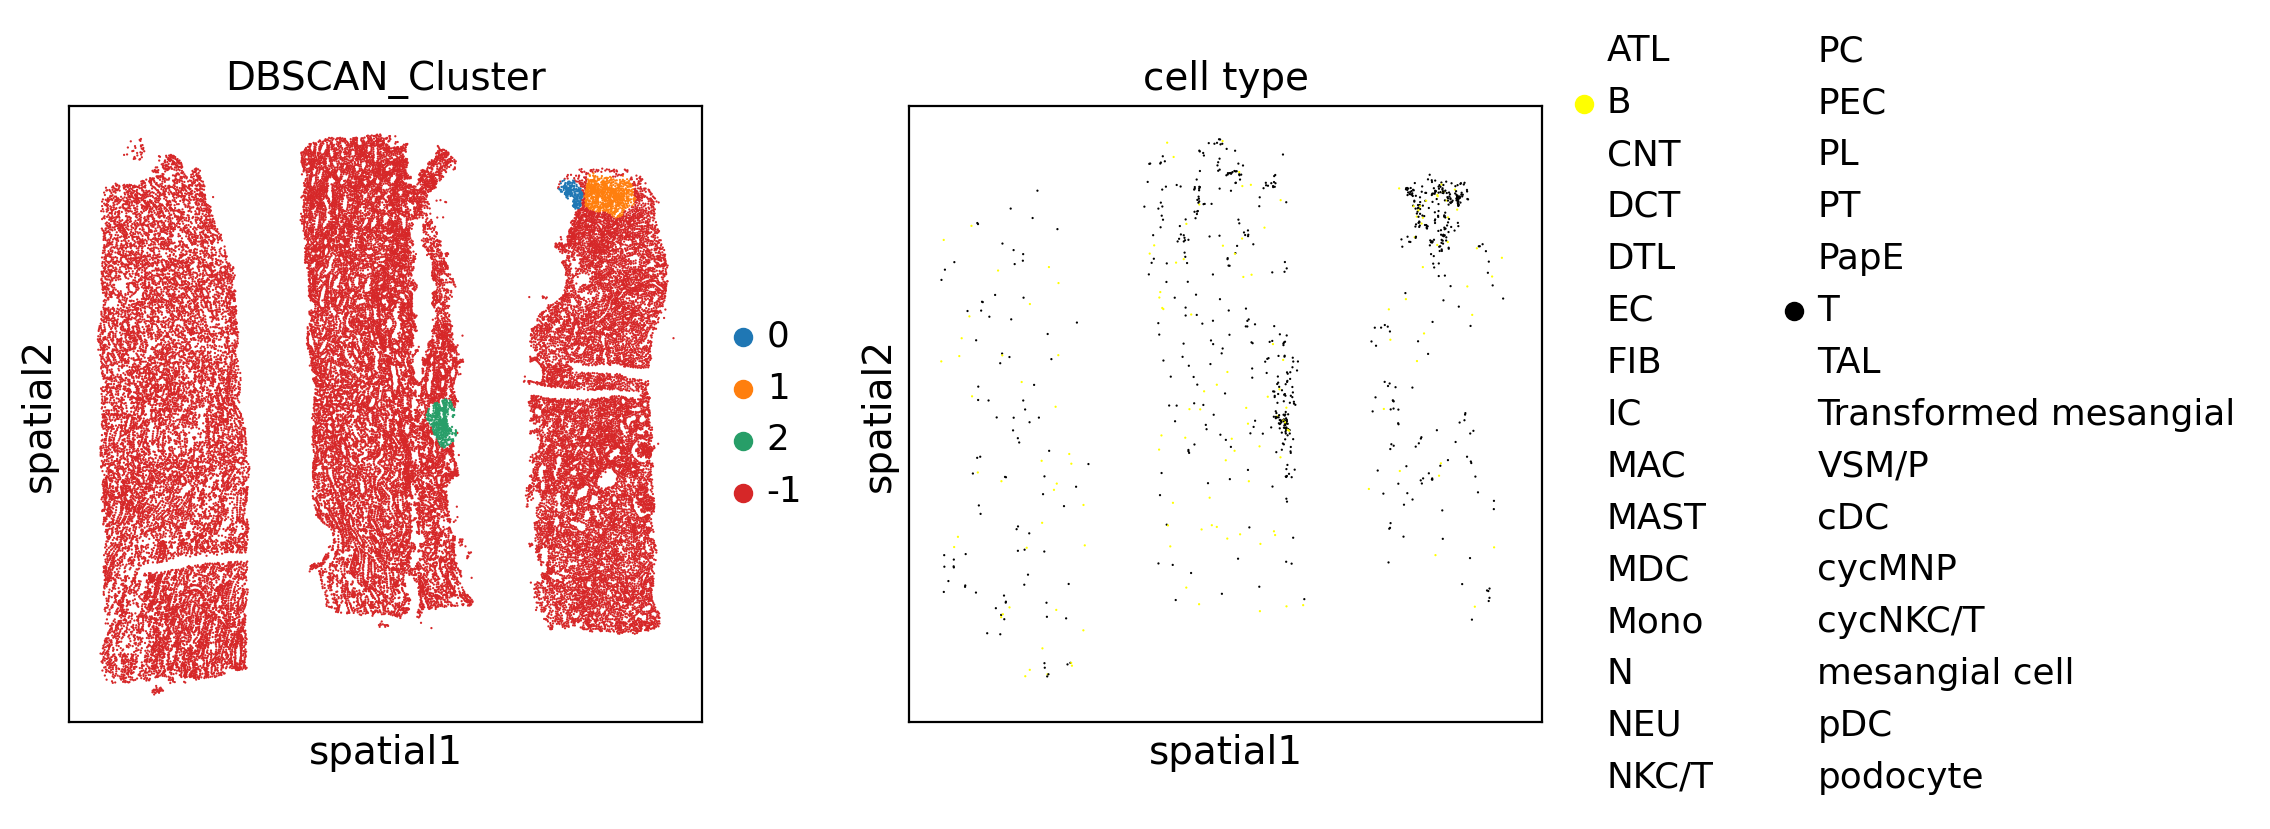

/tmp/ipykernel_3110/1817346483.py:9: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  sub.uns["cell_type_colors"] = []


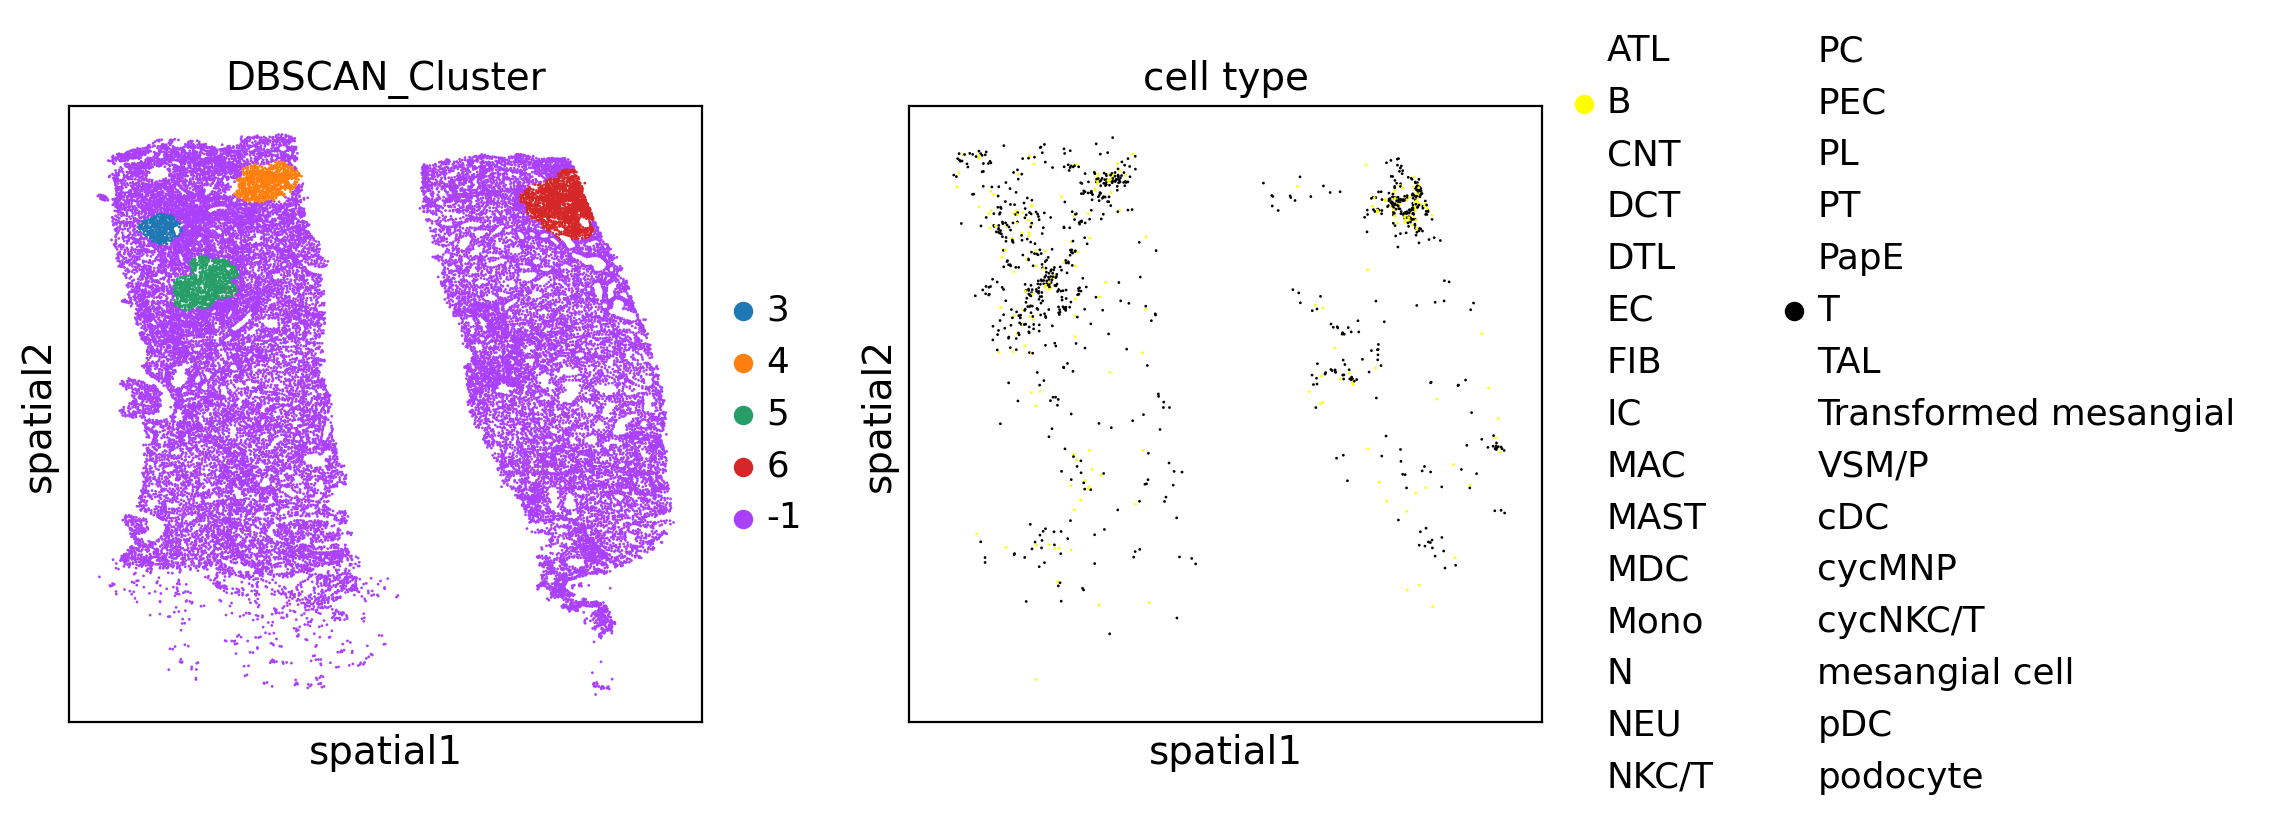

/tmp/ipykernel_3110/1817346483.py:9: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  sub.uns["cell_type_colors"] = []


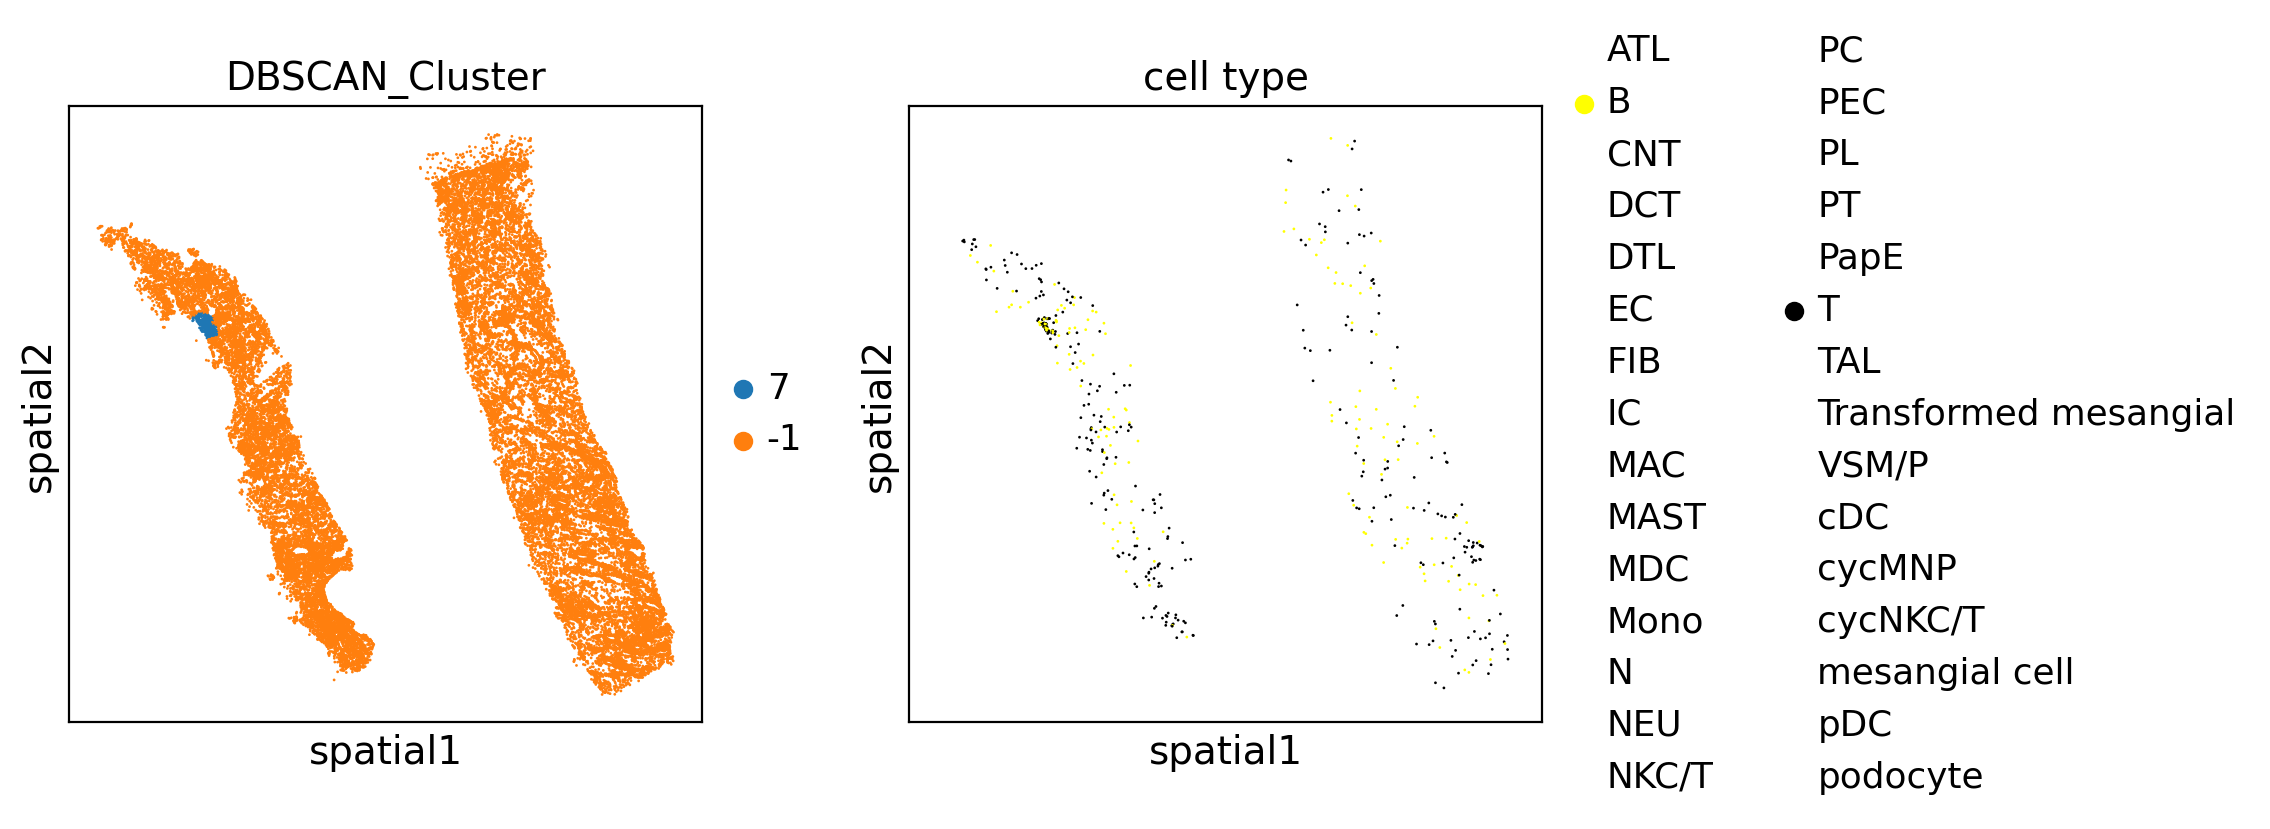

/tmp/ipykernel_3110/1817346483.py:9: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  sub.uns["cell_type_colors"] = []


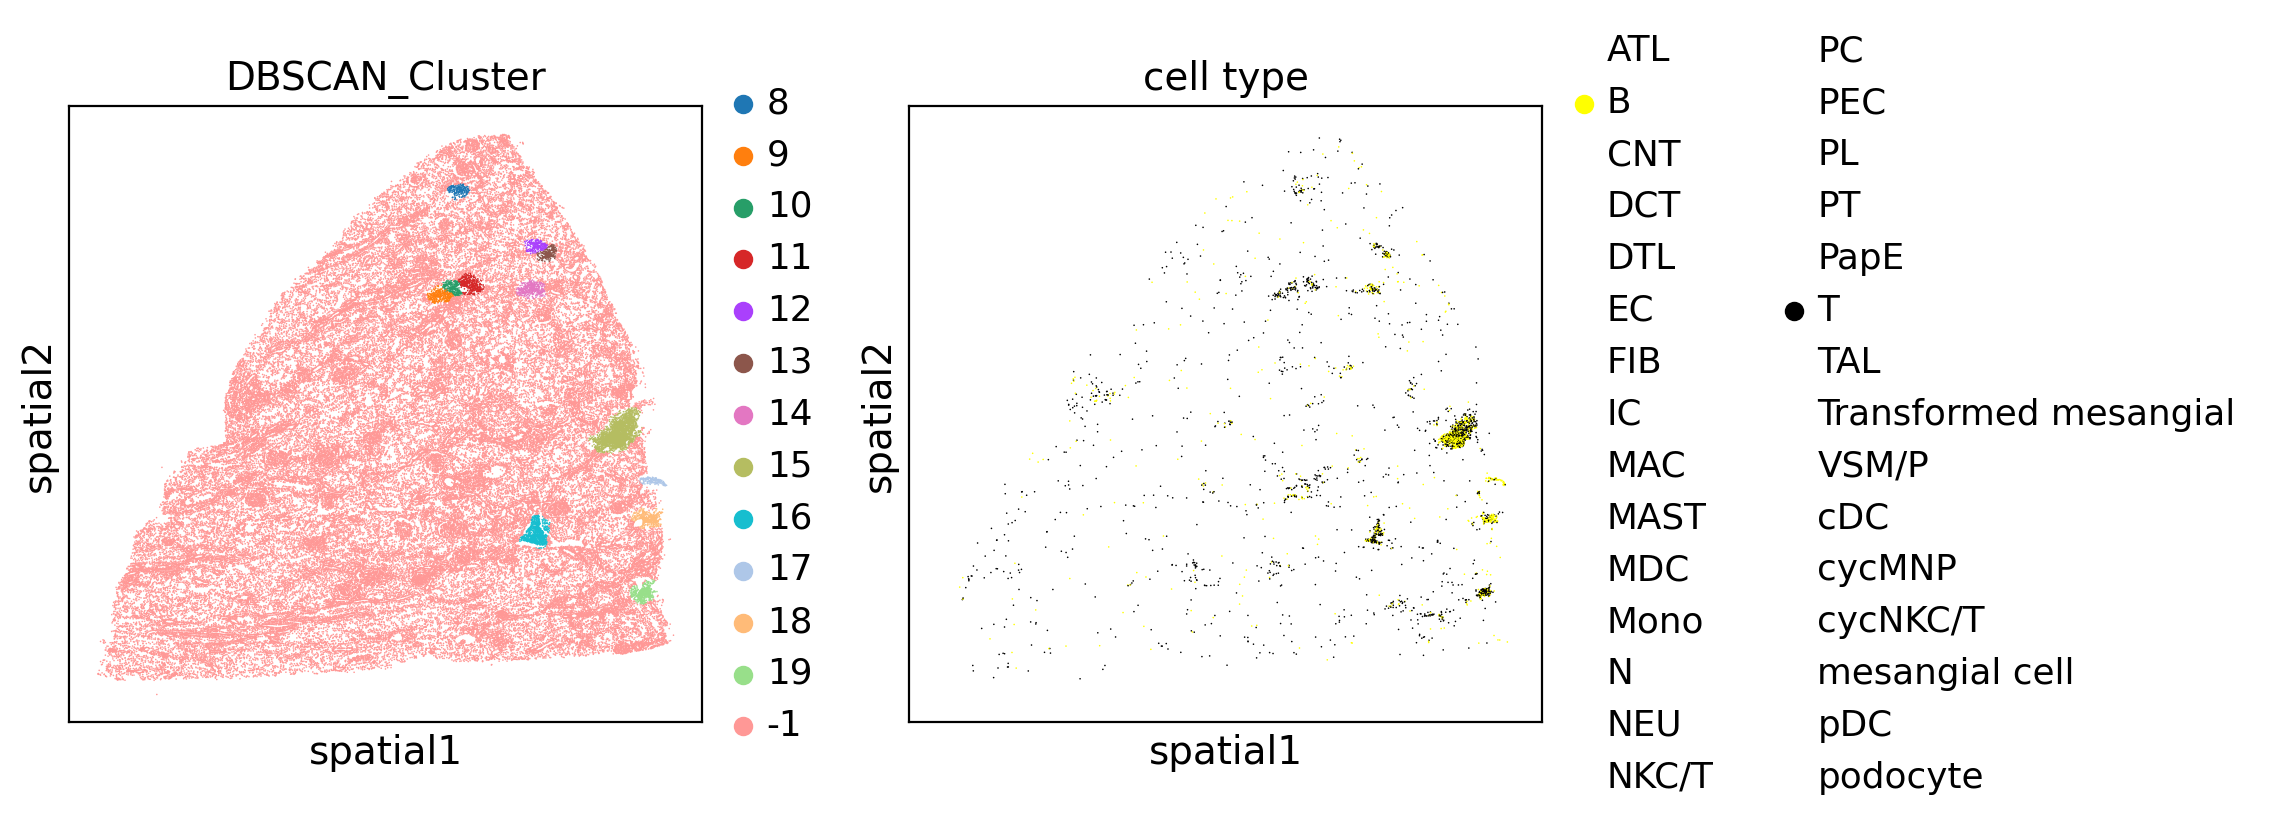

In [49]:
## show spatially

colors = {"T": "black",
          "B": "yellow"}
for slide in data.obs["Donor"].unique()[0:5]:
    sub = data[data.obs["Donor"]==slide]

    # to show only T and B cells
    sub.uns["cell_type_colors"] = []
    for celltype in sub.obs[celltype_col].cat.categories:
        if celltype in colors:
            sub.uns["cell_type_colors"].append(colors[celltype])
        else:
            sub.uns["cell_type_colors"].append("none")
        
    ax=sc.pl.embedding(sub, basis="spatial", color=["DBSCAN_cluster",
                                                   "cell_type"], title=["DBSCAN_Cluster",
                                                                         "cell type"], show=False,
                      )
    ax[0].invert_yaxis()
    ax[1].invert_yaxis() 
    plt.show()


In [62]:
## compare with nichePCA clusters

# assign all TLS clusters as TLS
data.obs["DBSCAN_cluster_1"] = "Other"
data.obs.loc[data.obs["DBSCAN_cluster"]!="-1", "DBSCAN_cluster_1"] = "TLS"
tab = pd.crosstab(data.obs["nichePCA_cluster"], data.obs["DBSCAN_cluster_1"])
tab.sort_values(by="TLS", ascending=False)

DBSCAN_cluster_1,Other,TLS
nichePCA_cluster,,
11,644,3136
0,25204,1783
14,349,1176
16,371,768
12,2955,566
3,20245,429
6,12520,409
1,26579,405
13,1181,357


most of the TLS cluster are in one of the nichePCA clusters but several others are missed.

<u>Tasks:</u>
1. Perform DBSCAN to annotate tubulointerstitial regions with high PT and immune cell presence.